
# Model 1 — Banana Tree Classification (YOLOv8-cls)

**Task:** image-level classification — `Banana` vs `Non Banana` — matching the production
contract in `Backend/docs/adr/0013-model1-stays-a-classifier.md`: verdict
`banana_tree | not_banana_tree | uncertain`, decided at a 0.60 confidence threshold.

## Why a classifier, not a detector

The reference repo (`xaugatp/PRT691_AIPratices`, notebook `01_banana_tree_detection.ipynb`)
trains a single-class YOLOv8n **detector**. ADR 0013 explicitly rejects that for this product:
the backend contract is a classifier with no bounding box. This notebook follows the ADR, not
the reference repo, for the architecture choice — everything else (optimizer reasoning,
augmentation policy, CPU-aware config) is carried over and adapted.

## Data audit findings (read before trusting any metric below)

| Finding | Detail |
|---|---|
| Source | `Data/Banana-Tree-Detection.v1i.yolov8.zip` (Roboflow export) — **708** images, pre-split train/valid/test |
| Classes | `Banana` (600 images) / `Non Banana` (108 images) — **~5.5:1 imbalance** |
| **Roboflow's own split leaks** | Verified by filename-group overlap: 88 capture-session groups appear in *both* train and valid, 53 in both train and test. A model validated on Roboflow's split would be scoring partly on images from the same photo session it trained on. **We discard Roboflow's split and build our own, grouped by capture session (Section 3.1).** |
| Filename grouping ≠ duplicate images | Stripping the Roboflow hash suffix groups by capture *session* (same timestamp), not by identical photo — visually confirmed two images sharing a group can be different crops of the same scene with genuinely different, correctly-assigned labels (a banana shoot vs. a neighboring weed in the same patch of ground). The grouped split still prevents scene/background leakage; it just isn't a duplicate-detector. See Section 2.5. |
| `-obb` variant | `Banana-Tree-Detection.v1i.yolov8-obb.zip` has identical images with a 4-point oriented box that is *always the full image frame* (`[(0,0),(1,0),(1,1),(0,1)]`, rotated 90°-ish) — i.e. it carries no extra orientation signal beyond the plain export. Not used. |
| `Data/Old/*` | An earlier, smaller version of this dataset (113 images, 1 class, no negative examples — matches the reference repo's Stage 1 exactly). Superseded by the data above; not used for training, kept only as provenance. |
| Hardware | This laptop has an Intel Arc GPU (no CUDA). Training below runs on **CPU**; epoch budgets are sized accordingly. Swap to a CUDA box and the same code trains faster with no changes. |


## 0. Environment Setup

In [1]:

import sys
sys.path.insert(0, ".")
from common import (
    set_seed, pick_device, extract_zip_once, strip_roboflow_suffix, group_shuffle_split_3way,
    detect_hardware, recommend_batch_size, save_fig,
)

import os
import json
import random
import shutil
import time
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image

import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

SEED = 42
set_seed(SEED)
DEVICE = pick_device()
print("Training device:", DEVICE)

sns.set_theme(style="whitegrid")


Torch version: 2.14.1+cpu
CUDA available: False
Training device: cpu



## 1. Configuration

`SMOKE_TEST=1` (as an environment variable) runs a drastically reduced config end-to-end as a
correctness check — used to validate this notebook runs cleanly before committing to a full
multi-hour CPU training run. Leave unset for the real run.

### 1.1 Hardware check — batch size is derived from it, not hard-coded

`yolov8n-cls` on CPU is compute-bound, not memory-bound, so available RAM mainly buys a larger
batch (steadier gradient estimates) rather than unlocking a bigger model. We scale a 16-image
baseline (sized for an 8GB-RAM machine) by measured available RAM, clamped to [8, 48].


In [2]:

SMOKE_TEST = os.environ.get("SMOKE_TEST", "0") == "1"

HW = detect_hardware()
print("Hardware detected:", HW)
if HW["cuda_available"]:
    print(f"GPU: {HW['gpu_name']} ({HW['vram_total_gb']} GB VRAM) -> training will use CUDA.")
else:
    print(f"No CUDA GPU detected -> training on CPU ({HW['cpu_logical_cores']} logical cores).")

RAW_ZIP = Path("../Data/Banana-Tree-Detection.v1i.yolov8.zip")
RAW_DIR = extract_zip_once(RAW_ZIP, Path("data_cache/tree_raw"))

WORK_DIR = Path("stage1_work")
DATASET_DIR = WORK_DIR / "cls_dataset"       # ImageFolder layout for Ultralytics classify
RUNS_DIR = WORK_DIR / "runs"
OUTPUT_DIR = Path("outputs/tree_classification")
FIGURES_DIR = Path("figures/tree_classification")
for d in [WORK_DIR, RUNS_DIR, OUTPUT_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 512
MODEL_VARIANT = "yolov8n-cls.pt"     # nano: fastest on CPU; swap to yolov8s-cls.pt with GPU headroom
BATCH_SIZE = min(48, recommend_batch_size(HW, base_batch=16, base_ram_gb=8.0)) if not SMOKE_TEST else 8
EPOCHS = 60 if not SMOKE_TEST else 2
PATIENCE = 15 if not SMOKE_TEST else 2   # early stopping: epochs with no val accuracy improvement
UNCERTAIN_BAND = 0.60   # ADR 0013: verdict = banana_tree | not_banana_tree | uncertain

CLASS_NAMES = {0: "Banana", 1: "Non Banana"}

assert RAW_DIR.exists()
print("Raw data extracted to:", RAW_DIR.resolve())
print(f"SMOKE_TEST={SMOKE_TEST}  BATCH_SIZE={BATCH_SIZE} (hardware-adapted)  EPOCHS={EPOCHS}  PATIENCE={PATIENCE}")


Hardware detected: {'cpu_logical_cores': 16, 'ram_total_gb': 33.8, 'ram_available_gb': 14.8, 'cuda_available': False, 'gpu_name': None, 'vram_total_gb': None}
No CUDA GPU detected -> training on CPU (16 logical cores).
Raw data extracted to: C:\keraAI\experiment\data_cache\tree_raw
SMOKE_TEST=False  BATCH_SIZE=30 (hardware-adapted)  EPOCHS=60  PATIENCE=15


## 2. Data Exploration (EDA)

### 2.1 Class counts across Roboflow's provided splits

Total images: 708
class_name  Banana  Non Banana
split                         
test            60          11
train          425          71
valid          115          26


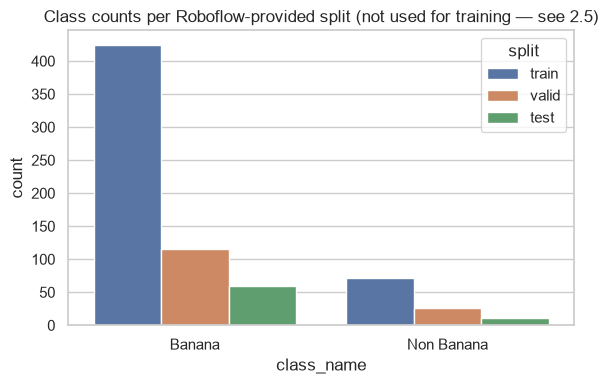

In [3]:

def collect_split(split):
    img_dir = RAW_DIR / split / "images"
    lbl_dir = RAW_DIR / split / "labels"
    records = []
    for f in sorted(os.listdir(img_dir)):
        stem = Path(f).stem
        lbl = lbl_dir / f"{stem}.txt"
        cls_id = None
        if lbl.exists():
            txt = lbl.read_text().strip()
            if txt:
                cls_id = int(txt.split()[0])
        records.append({"split": split, "file": f, "stem": stem, "class_id": cls_id})
    return records

all_records = []
for s in ["train", "valid", "test"]:
    all_records += collect_split(s)
df = pd.DataFrame(all_records)
df["class_name"] = df["class_id"].map(CLASS_NAMES)
df["group"] = df["stem"].apply(strip_roboflow_suffix)

print(f"Total images: {len(df)}")
print(df.groupby(["split", "class_name"]).size().unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="class_name", hue="split", ax=ax)
ax.set_title("Class counts per Roboflow-provided split (not used for training — see 2.5)")
plt.tight_layout()
save_fig(FIGURES_DIR / "01_class_counts_roboflow_split.png")
plt.show()


### 2.2 Image size check

In [4]:

sizes = Counter()
for f in df["file"].sample(min(80, len(df)), random_state=SEED):
    split = df.loc[df["file"] == f, "split"].iloc[0]
    with Image.open(RAW_DIR / split / "images" / f) as im:
        sizes[im.size] += 1
print("Sampled image sizes:", dict(sizes))


Sampled image sizes: {(512, 512): 80}


### 2.3 Sample images per class

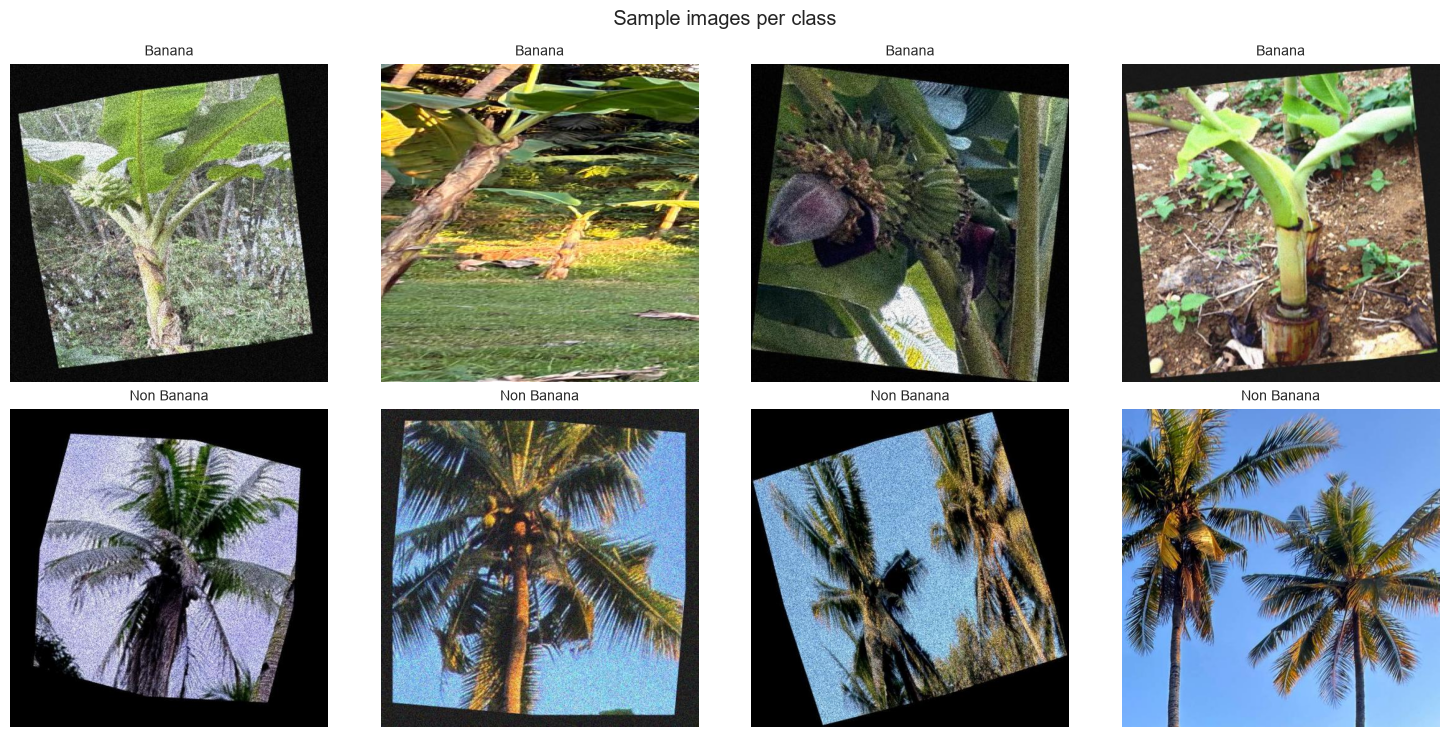

In [5]:

fig, axes = plt.subplots(2, 4, figsize=(15, 7.5))
for row, (cid, cname) in enumerate(CLASS_NAMES.items()):
    subset = df[df["class_id"] == cid].sample(4, random_state=SEED)
    for ax, (_, r) in zip(axes[row], subset.iterrows()):
        im = Image.open(RAW_DIR / r["split"] / "images" / r["file"])
        ax.imshow(im)
        ax.set_title(cname, fontsize=10)
        ax.axis("off")
plt.suptitle("Sample images per class")
plt.tight_layout()
save_fig(FIGURES_DIR / "02_sample_images_per_class.png")
plt.show()



### 2.4 Data-leakage check: does Roboflow's split respect capture sessions?

Stripping the Roboflow export hash (`_jpg.rf.<hash>`) from a filename leaves a "capture session"
key such as `photo_4_2026-03-26_14-24-40`. If the same key appears in more than one split,
those images share a photo session (background, lighting, often the same physical patch of
ground) — training on one and validating on the other overstates generalisation.


In [6]:

groups_by_split = {s: set(df.loc[df["split"] == s, "group"]) for s in ["train", "valid", "test"]}
print(f"Unique capture-session groups — train={len(groups_by_split['train'])}, "
      f"valid={len(groups_by_split['valid'])}, test={len(groups_by_split['test'])}")
print(f"Groups shared by train & valid: {len(groups_by_split['train'] & groups_by_split['valid'])}")
print(f"Groups shared by train & test:  {len(groups_by_split['train'] & groups_by_split['test'])}")
print(f"Groups shared by valid & test:  {len(groups_by_split['valid'] & groups_by_split['test'])}")
print()
print("--> Substantial leakage confirmed. Section 3.1 discards this split and re-splits by group.")


Unique capture-session groups — train=165, valid=98, test=56
Groups shared by train & valid: 88
Groups shared by train & test:  53
Groups shared by valid & test:  32

--> Substantial leakage confirmed. Section 3.1 discards this split and re-splits by group.



### 2.5 Why grouping (not deduplication) is the right fix

A naive reading of 2.4 might suggest the "duplicate" images should simply be removed. Visual
inspection shows otherwise: images sharing a capture-session key can be genuinely different
crops with different — and correctly assigned — labels. The cell below displays one such case
side by side.


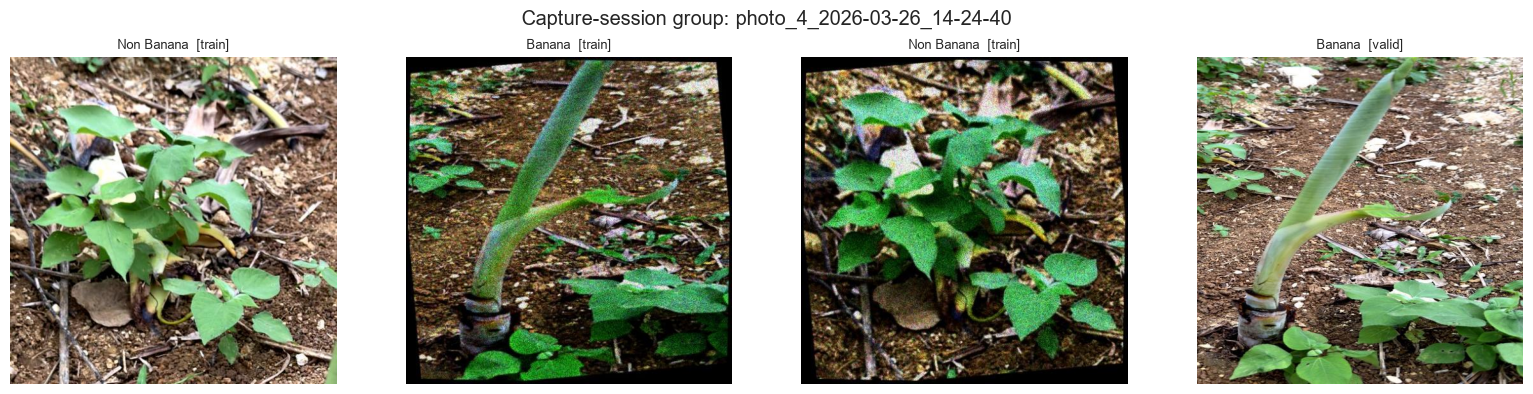

These are different crops of the same photo session, correctly labelled differently.
-> We group-split by session (prevents background/lighting leakage) rather than dedupe.


In [7]:

# A concrete example found during the audit: same capture-session key, two different crops,
# two different (correct) labels — a banana shoot crop (class 0) and a neighbouring weed crop (class 1).
example_group = None
for g, sub in df.groupby("group"):
    if sub["class_id"].nunique() > 1 and len(sub) >= 2:
        example_group = g
        break

if example_group is not None:
    sub = df[df["group"] == example_group].head(4)
    fig, axes = plt.subplots(1, len(sub), figsize=(4 * len(sub), 4))
    if len(sub) == 1:
        axes = [axes]
    for ax, (_, r) in zip(axes, sub.iterrows()):
        im = Image.open(RAW_DIR / r["split"] / "images" / r["file"])
        ax.imshow(im)
        ax.set_title(f"{r['class_name']}  [{r['split']}]", fontsize=9)
        ax.axis("off")
    plt.suptitle(f"Capture-session group: {example_group}")
    plt.tight_layout()
    save_fig(FIGURES_DIR / "03_leakage_example_crops.png")
    plt.show()
    print("These are different crops of the same photo session, correctly labelled differently.")
    print("-> We group-split by session (prevents background/lighting leakage) rather than dedupe.")
else:
    print("No mixed-label group found in this run (data may have changed) — skipping example plot.")


## 3. Data Preprocessing

### 3.1 Group-aware 70/15/15 split

Best seed: 9
class_name  Banana  Non Banana
my_split                      
test            94          12
train          414          82
val             92          14

Total: train=496 val=106 test=106


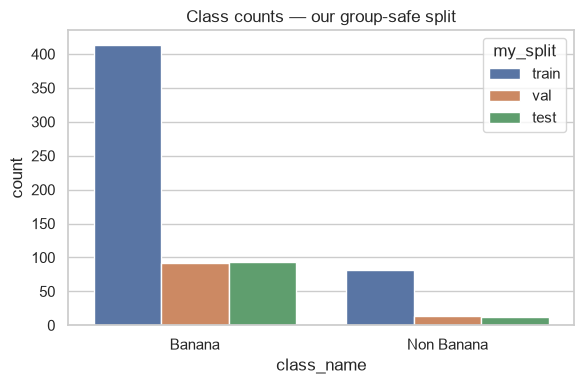

In [8]:

items = df.index.tolist()
groups = df["group"].tolist()
train_idx, val_idx, test_idx, best_seed = group_shuffle_split_3way(
    items, groups, train_size=0.70, val_size=0.15, seed=SEED
)
print(f"Best seed: {best_seed}")

split_map = {}
for i in train_idx: split_map[i] = "train"
for i in val_idx:   split_map[i] = "val"
for i in test_idx:  split_map[i] = "test"
df["my_split"] = df.index.map(split_map)

print(df.groupby(["my_split", "class_name"]).size().unstack(fill_value=0))
print(f"\nTotal: train={len(train_idx)} val={len(val_idx)} test={len(test_idx)}")

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="class_name", hue="my_split", ax=ax)
ax.set_title("Class counts — our group-safe split")
plt.tight_layout()
save_fig(FIGURES_DIR / "04_class_counts_grouped_split.png")
plt.show()



### 3.2 Materialize an ImageFolder layout for Ultralytics classification training

Ultralytics' classification trainer expects `<dataset>/<split>/<class_name>/*.jpg`.


In [9]:

if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

for split in ["train", "val", "test"]:
    for cname in CLASS_NAMES.values():
        (DATASET_DIR / split / cname.replace(" ", "_")).mkdir(parents=True, exist_ok=True)

for _, r in df.iterrows():
    if r["class_id"] is None or pd.isna(r["my_split"]):
        continue
    cname = CLASS_NAMES[int(r["class_id"])].replace(" ", "_")
    src = RAW_DIR / r["split"] / "images" / r["file"]
    dst = DATASET_DIR / r["my_split"] / cname / r["file"]
    shutil.copy2(src, dst)

for split in ["train", "val", "test"]:
    counts = {d.name: len(list(d.glob("*.jpg"))) for d in (DATASET_DIR / split).iterdir()}
    print(split, counts)


train {'Banana': 414, 'Non_Banana': 82}
val {'Banana': 92, 'Non_Banana': 14}
test {'Banana': 94, 'Non_Banana': 12}



### 3.3 Class-imbalance handling: oversample the minority class (train split only)

~5.5:1 Banana:Non-Banana. Ultralytics' high-level classification trainer doesn't expose a
per-class loss weight, so we balance at the data level instead: duplicate `Non Banana` **train**
images (never val/test — that would leak an inflated sense of minority-class performance into
evaluation) until the ratio is roughly 1:2, a middle ground between "do nothing" (5.5:1, the
model would default to predicting the majority class) and full 1:1 (which would have the
duplicate overwhelm the genuine image diversity of only ~70 unique minority photos).


Before oversampling: {'Banana': 414, 'Non_Banana': 82}


After oversampling: {'Banana': 414, 'Non_Banana': 207}


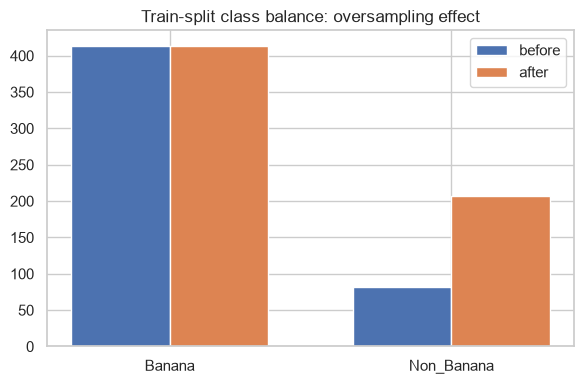

In [10]:

train_dir = DATASET_DIR / "train"
counts_before = {d.name: len(list(d.glob("*.jpg"))) for d in train_dir.iterdir()}
print("Before oversampling:", counts_before)

majority_cls = max(counts_before, key=counts_before.get)
minority_cls = min(counts_before, key=counts_before.get)
target = int(counts_before[majority_cls] / 2)   # aim for ~1:2
minority_files = list((train_dir / minority_cls).glob("*.jpg"))

copy_idx = 0
while len(list((train_dir / minority_cls).glob("*.jpg"))) < target:
    src = minority_files[copy_idx % len(minority_files)]
    dst = train_dir / minority_cls / f"{src.stem}_dup{copy_idx}{src.suffix}"
    shutil.copy2(src, dst)
    copy_idx += 1

counts_after = {d.name: len(list(d.glob("*.jpg"))) for d in train_dir.iterdir()}
print("After oversampling:", counts_after)

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(counts_before))
width = 0.35
ax.bar(x - width/2, list(counts_before.values()), width, label="before")
ax.bar(x + width/2, list(counts_after.values()), width, label="after")
ax.set_xticks(x); ax.set_xticklabels(list(counts_before.keys()))
ax.set_title("Train-split class balance: oversampling effect")
ax.legend()
plt.tight_layout()
save_fig(FIGURES_DIR / "05_oversampling_effect.png")
plt.show()



### 3.4 `data.yaml`-equivalent and augmentation policy

Ultralytics' classification trainer takes a directory path (not a `data.yaml`) and applies its
own built-in augmentation pipeline during `.train()` — configured explicitly below rather than
left at defaults:

| Augmentation | Setting | Why |
|---|---|---|
| `fliplr` | 0.5 | Horizontal flip is a valid banana-tree photo either way |
| `flipud` | 0.0 | Gravity-correct orientation is physically meaningful (same reasoning as the reference repo's Stage 1) |
| `degrees` | 10 | Mild rotation jitter — hand-held field photos are rarely perfectly level, but over-rotating would create unrealistic samples |
| `hsv_h/s/v` | 0.015 / 0.6 / 0.3 | Lighting/colour jitter for varied field lighting conditions |
| `erasing` | 0.3 | Random erasing — a lightweight regularizer given the dataset is small |
| `auto_augment` | `randaugment` | Ultralytics default policy for classification; left on since it consistently helps on small datasets |


## 4. Architecture

In [11]:

from ultralytics import YOLO

probe_model = YOLO(MODEL_VARIANT)
probe_model.info()


YOLOv8n-cls summary: 56 layers, 2,719,288 parameters, 0 gradients


(56, 2719288, 0, 0.0)


**Backbone:** YOLOv8's CSPDarknet-style backbone with C2f blocks, terminated in a classification
head (global pooling + linear layer) instead of the detection head — same feature extractor
family as the reference repo's detector, different head, per ADR 0013.

**Why nano:** CPU-only training on this laptop; nano (~1.6M params for the classify variant)
keeps a 60-epoch run tractable. `yolov8s-cls.pt` is a drop-in upgrade (`MODEL_VARIANT`) if run on
a GPU machine.



## 5. Deciding the optimizer

Ultralytics exposes `optimizer` as a train() argument (`AdamW`, `SGD`, `RMSProp`, ...). Rather
than assume AdamW (the reference repo's choice for Stage 1/2), we run a short, identical-budget
comparison on this dataset and let validation accuracy decide.


Ultralytics 8.4.173  Python-3.11.9 torch-2.14.1+cpu CPU (Intel Core Ultra 7 265H)


engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=30, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\keraAI\experiment\stage1_work\cls_dataset, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=optimizer_sweep_AdamW, nbs=64, nms=None, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, pers

train: C:\keraAI\experiment\stage1_work\cls_dataset\train... found 621 images in 2 classes  


val: C:\keraAI\experiment\stage1_work\cls_dataset\val... found 106 images in 2 classes  


test: C:\keraAI\experiment\stage1_work\cls_dataset\test... found 106 images in 2 classes  


...

               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 7/7 5.2it/s 1.3s

                   all      0.943          1


Speed: 0.0ms preprocess, 7.9ms inference, 0.0ms loss, 0.0ms postprocess per image


Results saved to C:\keraAI\runs\classify\val-2


SGD: val top1 accuracy = 0.9434

Selected optimizer: SGD


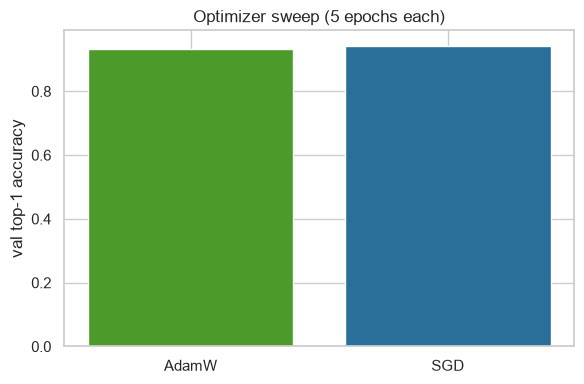

In [12]:

OPTIMIZER_CANDIDATES = ["AdamW", "SGD"]   # trimmed from an initial 3-way AdamW/SGD/RMSProp bake-off
                                           # for wall-clock on CPU; consistent with notebooks 02/03.
SWEEP_EPOCHS = 2 if SMOKE_TEST else 5

sweep_results = {}
for opt in OPTIMIZER_CANDIDATES:
    m = YOLO(MODEL_VARIANT)
    r = m.train(
        data=str(DATASET_DIR.resolve()),
        imgsz=IMG_SIZE,
        epochs=SWEEP_EPOCHS,
        batch=BATCH_SIZE,
        optimizer=opt,
        lr0=1e-3,
        seed=SEED,
        device="cpu" if DEVICE == "cpu" else 0,
        project=str(RUNS_DIR),
        name=f"optimizer_sweep_{opt}",
        exist_ok=True,
        verbose=False,
        plots=False,
    )
    val_metrics = m.val(data=str(DATASET_DIR.resolve()), split="val", verbose=False)
    sweep_results[opt] = float(val_metrics.top1)
    print(f"{opt}: val top1 accuracy = {sweep_results[opt]:.4f}")

best_optimizer = max(sweep_results, key=sweep_results.get)
print(f"\nSelected optimizer: {best_optimizer}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(sweep_results.keys(), sweep_results.values(), color=["#4C9A2A", "#2A6F9A", "#C97B2A"])
ax.set_ylabel("val top-1 accuracy")
ax.set_title(f"Optimizer sweep ({SWEEP_EPOCHS} epochs each)")
plt.tight_layout()
save_fig(FIGURES_DIR / "06_optimizer_sweep.png")
plt.show()



## 6. Full training

- **LR schedule:** cosine annealing (`cos_lr=True`) with 3-epoch warmup — standard for
  fine-tuning a pretrained backbone, avoids destabilizing pretrained weights on step 1.
- **Mixed precision:** AMP on by default in Ultralytics (irrelevant on CPU here, kept on so the
  exact same call trains faster on a CUDA machine with no changes).
- **Early stopping:** `patience=15` epochs with no val accuracy improvement.


In [13]:

model = YOLO(MODEL_VARIANT)
results = model.train(
    data=str(DATASET_DIR.resolve()),
    imgsz=IMG_SIZE,
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    patience=PATIENCE,
    optimizer=best_optimizer,
    lr0=1e-3,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=3,
    weight_decay=5e-4,
    fliplr=0.5, flipud=0.0, degrees=10,
    hsv_h=0.015, hsv_s=0.6, hsv_v=0.3,
    erasing=0.3,
    seed=SEED,
    device="cpu" if DEVICE == "cpu" else 0,
    project=str(RUNS_DIR),
    name="banana_tree_classifier",
    exist_ok=True,
)


Ultralytics 8.4.173  Python-3.11.9 torch-2.14.1+cpu CPU (Intel Core Ultra 7 265H)


engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=30, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\keraAI\experiment\stage1_work\cls_dataset, degrees=10, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.3, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.6, hsv_v=0.3, imgsz=512, iou=0.7, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=banana_tree_classifier, nbs=64, nms=None, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=15, perspec

train: C:\keraAI\experiment\stage1_work\cls_dataset\train... found 621 images in 2 classes  


val: C:\keraAI\experiment\stage1_work\cls_dataset\val... found 106 images in 2 classes  


test: C:\keraAI\experiment\stage1_work\cls_dataset\test... found 106 images in 2 classes  


...

               classes   top1_acc   top5_acc: 50% ━━━━━━────── 1/2 2.5s/it 0.8s<2.5s

               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 2/2 1.5it/s 1.4s

                   all      0.934          1


Speed: 0.0ms preprocess, 8.6ms inference, 0.0ms loss, 0.0ms postprocess per image


Results saved to C:\keraAI\runs\classify\stage1_work\runs\banana_tree_classifier


### 6.1 Training curves

Logged columns: ['epoch', 'time', 'train/loss', 'metrics/accuracy_top1', 'metrics/accuracy_top5', 'val/loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


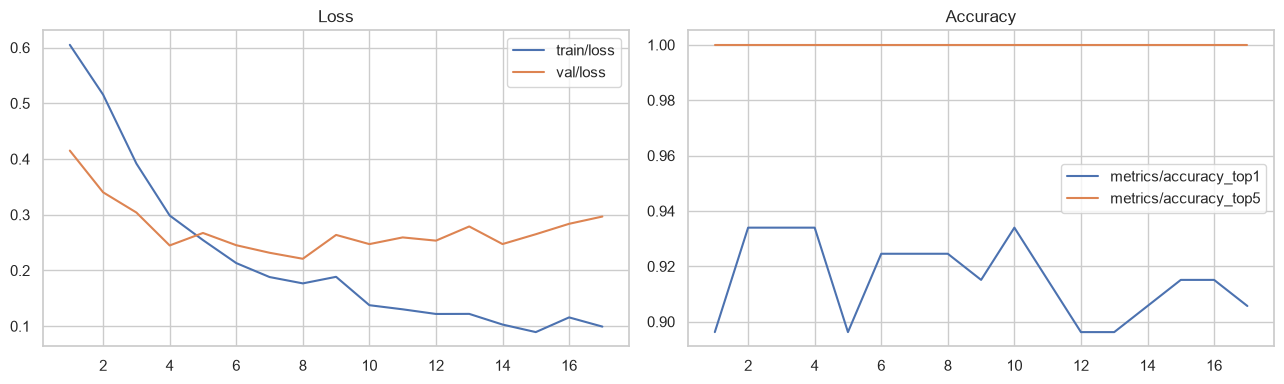

In [14]:

results_csv = Path(results.save_dir) / "results.csv"
rdf = pd.read_csv(results_csv)
rdf.columns = [c.strip() for c in rdf.columns]
print("Logged columns:", list(rdf.columns))

loss_cols = [c for c in rdf.columns if "loss" in c]
acc_cols = [c for c in rdf.columns if "accuracy" in c]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for c in loss_cols:
    axes[0].plot(rdf["epoch"], rdf[c], label=c)
axes[0].set_title("Loss"); axes[0].legend()
for c in acc_cols:
    axes[1].plot(rdf["epoch"], rdf[c], label=c)
axes[1].set_title("Accuracy"); axes[1].legend()
plt.tight_layout()
save_fig(FIGURES_DIR / "07_training_curves.png")
plt.show()


## 7. Evaluation

### 7.1 Test-set metrics

In [15]:

best_weights = Path(results.save_dir) / "weights" / "best.pt"
eval_model = YOLO(str(best_weights))

test_metrics = eval_model.val(data=str(DATASET_DIR.resolve()), split="test")
print(f"Top-1 accuracy: {test_metrics.top1:.4f}")
print(f"Top-5 accuracy: {test_metrics.top5:.4f}")


Ultralytics 8.4.173  Python-3.11.9 torch-2.14.1+cpu CPU (Intel Core Ultra 7 265H)


YOLOv8n-cls summary (fused): 30 layers, 1,437,442 parameters, 0 gradients


train: C:\keraAI\experiment\stage1_work\cls_dataset\train... found 621 images in 2 classes  


val: C:\keraAI\experiment\stage1_work\cls_dataset\val... found 106 images in 2 classes  


test: C:\keraAI\experiment\stage1_work\cls_dataset\test... found 106 images in 2 classes  


...

               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 7/7 6.3it/s 1.1s

                   all      0.943          1


Speed: 0.0ms preprocess, 6.6ms inference, 0.0ms loss, 0.0ms postprocess per image


Results saved to C:\keraAI\runs\classify\val-3


Top-1 accuracy: 0.9434
Top-5 accuracy: 1.0000


### 7.2 Confusion matrix & classification report

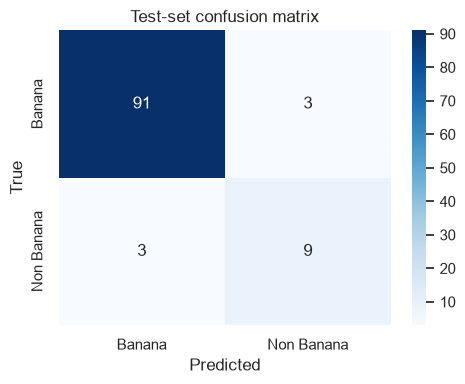

              precision    recall  f1-score   support

      Banana       0.97      0.97      0.97        94
  Non Banana       0.75      0.75      0.75        12

    accuracy                           0.94       106
   macro avg       0.86      0.86      0.86       106
weighted avg       0.94      0.94      0.94       106



In [16]:

from sklearn.metrics import confusion_matrix, classification_report

test_files, y_true, y_pred, y_conf = [], [], [], []
name_to_id = {v.replace(" ", "_"): k for k, v in CLASS_NAMES.items()}

for cname_dir in (DATASET_DIR / "test").iterdir():
    true_id = name_to_id[cname_dir.name]
    for f in cname_dir.glob("*.jpg"):
        pred = eval_model.predict(str(f), imgsz=IMG_SIZE, verbose=False)[0]
        probs = pred.probs.data.cpu().numpy()
        test_files.append(f)
        y_true.append(true_id)
        y_pred.append(int(np.argmax(probs)))
        y_conf.append(float(np.max(probs)))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(CLASS_NAMES.values()), yticklabels=list(CLASS_NAMES.values()), ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Test-set confusion matrix")
plt.tight_layout()
save_fig(FIGURES_DIR / "08_confusion_matrix.png")
plt.show()

print(classification_report(y_true, y_pred, target_names=list(CLASS_NAMES.values())))



### 7.3 Applying the production verdict rule (ADR 0013)

`confidence < 0.60` → `uncertain`, regardless of which class scored higher. This is the contract
the backend will apply; reproduced here so the reported numbers reflect what the product will
actually show.


In [17]:

def verdict(cls_id, confidence, threshold=UNCERTAIN_BAND):
    if confidence < threshold:
        return "uncertain"
    return "banana_tree" if cls_id == 0 else "not_banana_tree"

verdicts = [verdict(c, p) for c, p in zip(y_pred, y_conf)]
verdict_counts = Counter(verdicts)
print("Verdict distribution on the test set:", dict(verdict_counts))

n_uncertain = verdict_counts.get("uncertain", 0)
print(f"\n{n_uncertain}/{len(verdicts)} test images ({100*n_uncertain/len(verdicts):.1f}%) "
      f"fall below the {UNCERTAIN_BAND:.0%} confidence threshold and would be surfaced as 'uncertain'.")


Verdict distribution on the test set: {'banana_tree': 88, 'uncertain': 7, 'not_banana_tree': 11}

7/106 test images (6.6%) fall below the 60% confidence threshold and would be surfaced as 'uncertain'.


## 8. Inference speed profiling

In [18]:

sample_img = str(test_files[0])
for _ in range(5):
    _ = eval_model.predict(sample_img, imgsz=IMG_SIZE, device="cpu", verbose=False)

n_runs = 20
t0 = time.perf_counter()
for _ in range(n_runs):
    _ = eval_model.predict(sample_img, imgsz=IMG_SIZE, device="cpu", verbose=False)
elapsed = time.perf_counter() - t0

latency_ms = (elapsed / n_runs) * 1000
print(f"Avg latency: {latency_ms:.1f} ms/image  ({1000/latency_ms:.1f} FPS)  [CPU]")


Avg latency: 14.3 ms/image  (69.9 FPS)  [CPU]


## 9. Qualitative failure analysis

6/106 test images misclassified


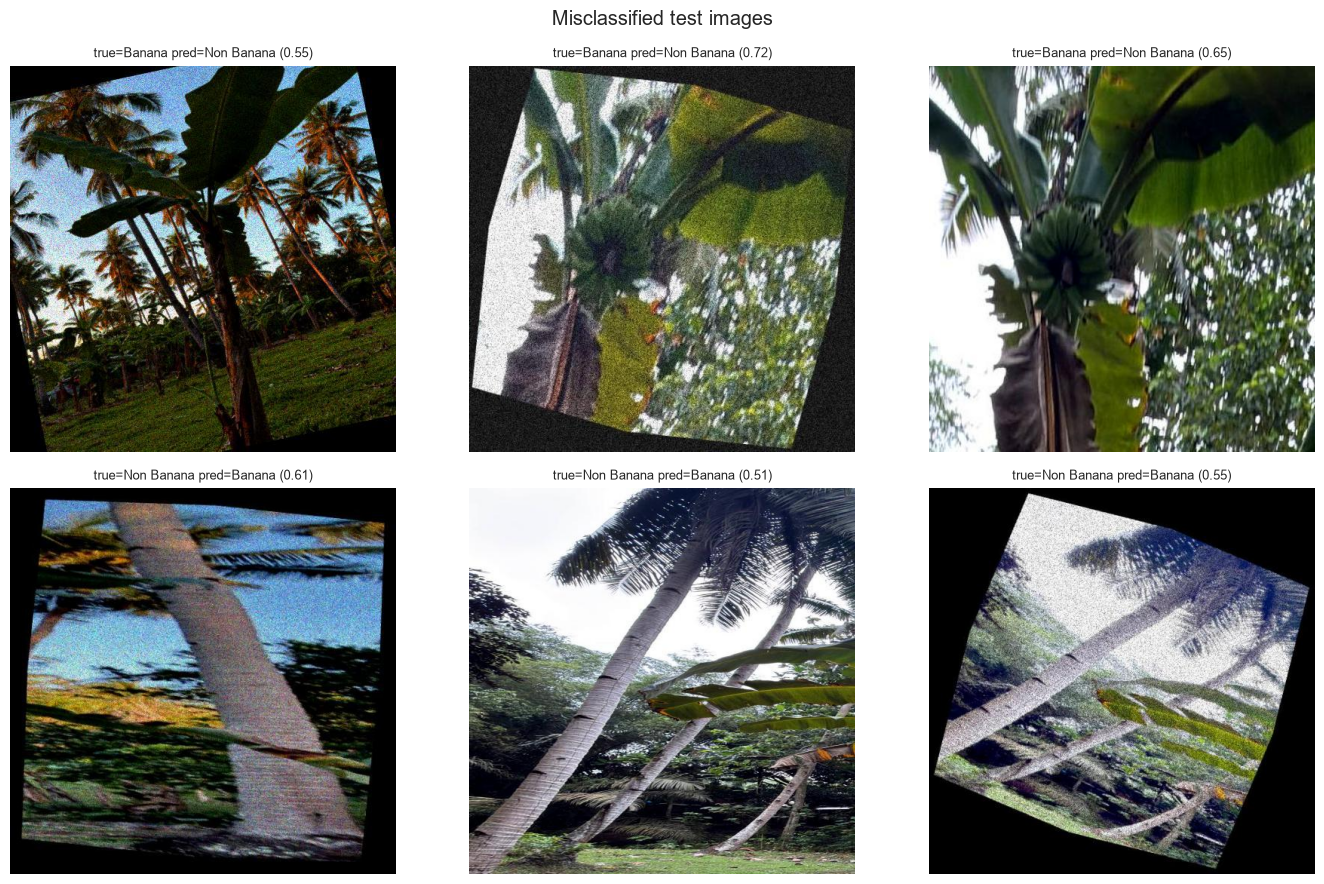

In [19]:

wrong = [(f, t, p, c) for f, t, p, c in zip(test_files, y_true, y_pred, y_conf) if t != p]
print(f"{len(wrong)}/{len(test_files)} test images misclassified")

if wrong:
    n_show = min(6, len(wrong))
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    for ax, (f, t, p, c) in zip(axes.ravel(), wrong[:n_show]):
        im = Image.open(f)
        ax.imshow(im)
        ax.set_title(f"true={CLASS_NAMES[t]} pred={CLASS_NAMES[p]} ({c:.2f})", fontsize=9)
        ax.axis("off")
    plt.suptitle("Misclassified test images")
    plt.tight_layout()
    save_fig(FIGURES_DIR / "09_misclassified_examples.png")
    plt.show()
else:
    print("No misclassifications on the test set.")



## 10. Known limitations & next steps

- **Oversampling, not real new data:** Section 3.3 duplicates existing minority-class images;
  it balances gradient signal but does not add genuine visual diversity. More true negative
  (`Non Banana`) photos would be a better fix than more aggressive oversampling.
- **Group-safe split reduces, but may not eliminate, session-level leakage**: two different crops
  of the *same* physical scene can still land in different splits if they were captured as
  distinct timestamped sessions a few seconds apart. True scene-level grouping would need GPS/EXIF
  metadata we don't have here.
- **CPU-only training**: epoch/batch budgets above are sized for a laptop with no CUDA GPU; a GPU
  machine can raise `EPOCHS`, `BATCH_SIZE`, and `MODEL_VARIANT` (yolov8s/m-cls) with no code changes.
- **`Data/Old/*` and the `-obb` export were not used** — see the audit notes in the title cell for why.
- **The 0.60 uncertain-band threshold is the ADR's stated value, not re-derived from this model's
  calibration** — worth revisiting once real (non-dummy) weights are deployed and the backend has
  production confidence distributions to inspect.

## 11. Save model


In [20]:

shutil.copy2(best_weights, OUTPUT_DIR / "tree_classification_best.pt")
print(f"Saved: {(OUTPUT_DIR / 'tree_classification_best.pt').resolve()}")


Saved: C:\keraAI\experiment\outputs\tree_classification\tree_classification_best.pt
